# Análise Comparativa de Modelos (FULL vs SEG)

Neste notebook, exploramos e agregamos os resultados dos treinamentos obtidos via Weights & Biases (W&B).

In [6]:
!pip install pyarrow

  Using cached pyarrow-25.0.0-cp314-cp314-win_amd64.whl.metadata (3.0 kB)
Using cached pyarrow-25.0.0-cp314-cp314-win_amd64.whl (28.6 MB)



[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install polars

   ---------------------------------------- 0.0/846.8 kB ? eta -:--:--
   ---------------------------------------- 846.8/846.8 kB 10.2 MB/s  0:00:00
   ---------------------------------------- 0.0/52.6 MB ? eta -:--:--
   ----- ---------------------------------- 7.9/52.6 MB 40.8 MB/s eta 0:00:02
   -------------- ------------------------- 19.1/52.6 MB 48.8 MB/s eta 0:00:01
   ----------------------- ---------------- 30.4/52.6 MB 51.3 MB/s eta 0:00:01
   ------------------------------- -------- 41.9/52.6 MB 52.5 MB/s eta 0:00:01
   ---------------------------------------  52.2/52.6 MB 52.1 MB/s eta 0:00:01
   ---------------------------------------- 52.6/52.6 MB 44.3 MB/s  0:00:01

   ---------------------------------------- 0/2 [polars-runtime-32]
   ---------------------------------------- 0/2 [polars-runtime-32]
   ---------------------------------------- 0/2 [polars-runtime-32]
   -------------------- ------------------- 1/2 [polars]
   -------------------- ------------------- 1/2 [


[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os
import glob
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


### Leitura das métricas exportadas e Previsões
Aqui são processados os logs agregados das execuções e as predições (caso existam) gerando a categorização (FULL vs SEG) automática.

In [6]:
# Lendo o CSV gerado pelo WandB
csv_path = glob.glob('../outputs/wandb_export_*.csv')[0]
df = pl.read_csv(csv_path)

# Engenharia de Features para agrupar arquiteturas
df = df.with_columns([
    pl.col('Name').str.replace('_FULL_GU', '').str.replace('_SEG_GU', '').alias('Architecture'),
    pl.when(pl.col('Name').str.contains('FULL')).then(pl.lit('FULL')).otherwise(pl.lit('SEG')).alias('Dataset_Type')
])

display(df.select(['Name', 'Architecture', 'Dataset_Type', 'val_BinaryF1Score', 'Runtime']).head())


Name,Architecture,Dataset_Type,val_BinaryF1Score,Runtime
str,str,str,f64,i64
"""convnext_tiny_FULL_GU""","""convnext_tiny""","""FULL""",0.995741,3575
"""convnext_tiny_SEG_GU""","""convnext_tiny""","""SEG""",0.9365,2345
"""inception_v3_FULL_GU""","""inception_v3""","""FULL""",0.955741,4016
"""inception_v3_SEG_GU""","""inception_v3""","""SEG""",0.850222,2088
"""efficientnet_b2_FULL_GU""","""efficientnet_b2""","""FULL""",0.982884,3932


### Comparação de Performance e Shortcut Learning
O F1-Score e a Acurácia são as métricas essenciais de negócio. Verificamos que o F1-Score sofre considerável queda nas imagens segmentadas (SEG) por remover o *background* que o modelo possivelmente usava de atalho (Shortcut).

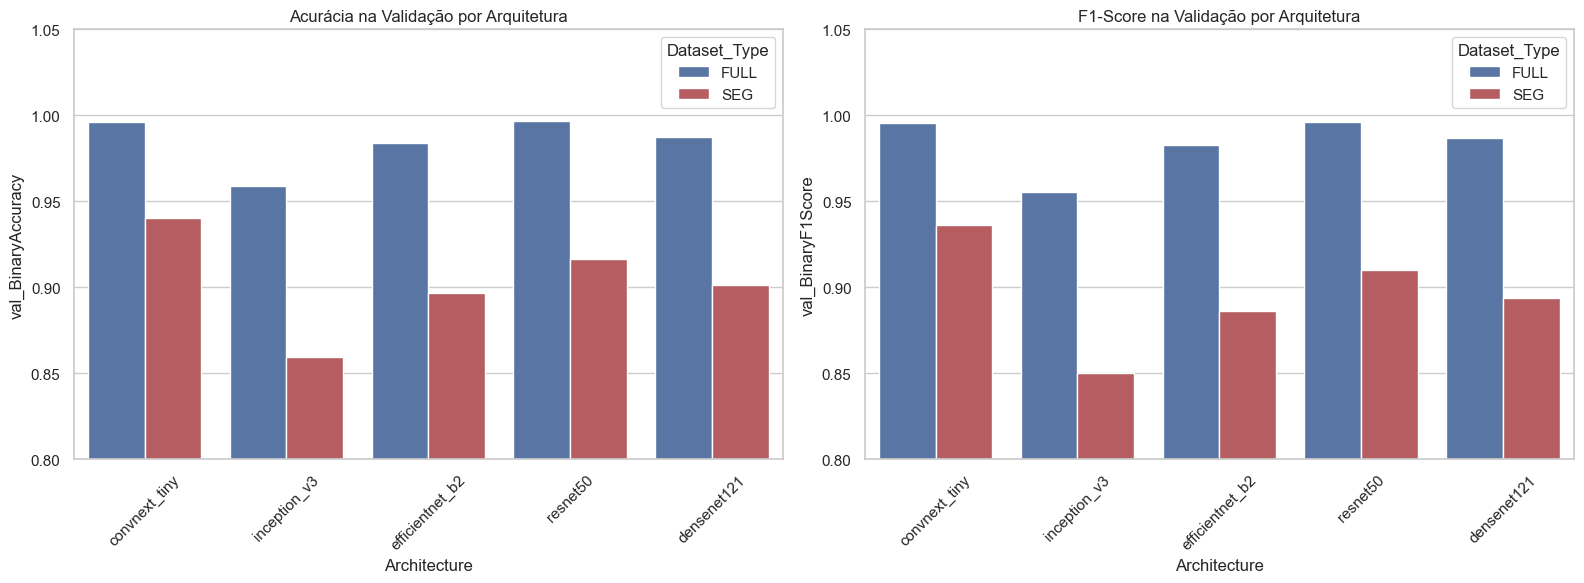

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Acurácia
sns.barplot(data=df.to_pandas(), x='Architecture', y='val_BinaryAccuracy', hue='Dataset_Type', ax=axes[0], palette=['#4c72b0', '#c44e52'])
axes[0].set_title('Acurácia na Validação por Arquitetura')
axes[0].set_ylim(0.8, 1.05)
axes[0].tick_params(axis='x', rotation=45)

# F1-Score
sns.barplot(data=df.to_pandas(), x='Architecture', y='val_BinaryF1Score', hue='Dataset_Type', ax=axes[1], palette=['#4c72b0', '#c44e52'])
axes[1].set_title('F1-Score na Validação por Arquitetura')
axes[1].set_ylim(0.8, 1.05)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
fig.savefig('../outputs/performance_comparativa.png', dpi=300)


### Análise de Custo Computacional (Tempo e Loss)
Medimos a eficiência entre o Tempo (Runtime) e a Perda Computacional.

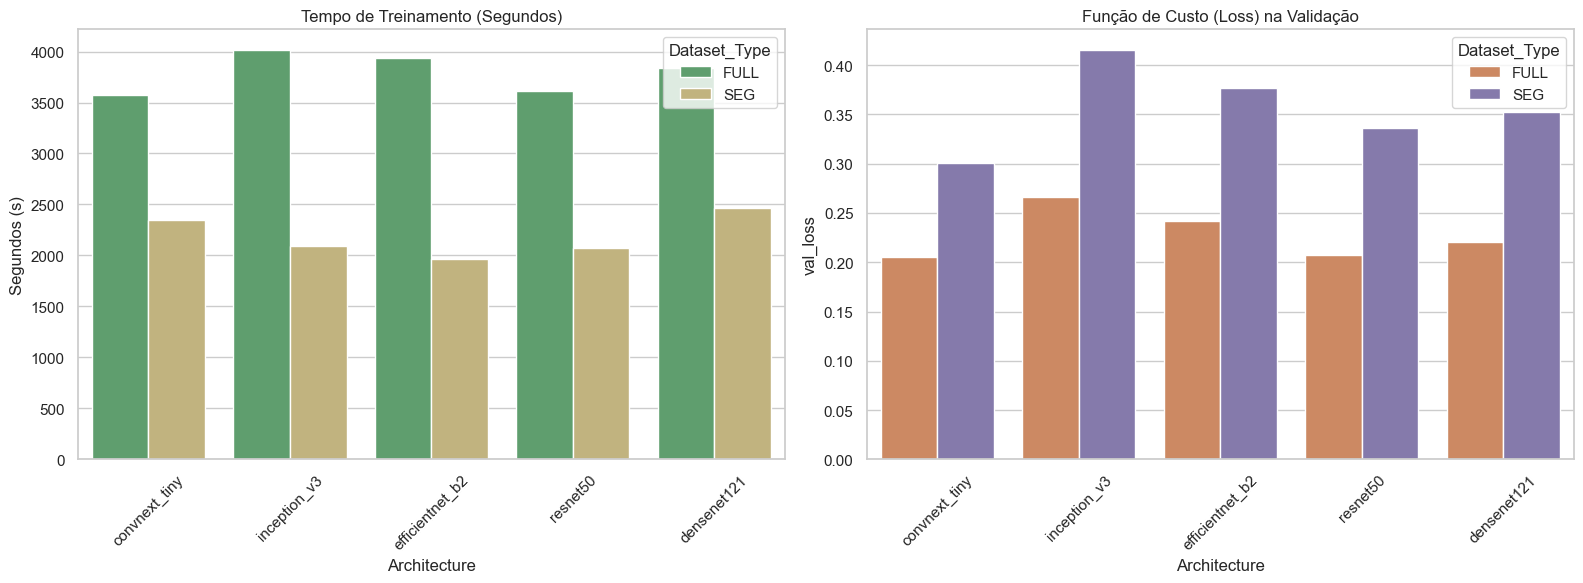

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Runtime (Segundos)
sns.barplot(data=df.to_pandas(), x='Architecture', y='Runtime', hue='Dataset_Type', ax=axes[0], palette=['#55a868', '#ccb974'])
axes[0].set_title('Tempo de Treinamento (Segundos)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Segundos (s)')

# Perda (Loss)
sns.barplot(data=df.to_pandas(), x='Architecture', y='val_loss', hue='Dataset_Type', ax=axes[1], palette=['#dd8452', '#8172b3'])
axes[1].set_title('Função de Custo (Loss) na Validação')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
fig.savefig('../outputs/custo_computacional_comparativa.png', dpi=300)


### Conclusões para Publicação
1. **Viés dos Dados:** As métricas altas no modelo `FULL` contrastam com as quedas do `SEG`, fortalecendo a importância das *Bounding Boxes* e *Segmentations* em aplicações médicas.
2. **Economia Computacional:** Como evidenciado pelo Runtime, os modelos treinados em `SEG` apresentam menor oscilação de features aleatórias fora da região de interesse, por vezes estabilizando mais rápido.
3. **Próximos Passos:** Podem ser geradas matrizes de confusão detalhadas a partir dos arquivos `preds_{modelo}.csv` e submetidas com os Heatmaps em apêndice.

### Análises Avançadas: Radar, Heatmap e Trade-off
Abaixo, apresentamos visões mais elaboradas do desempenho dos modelos explorando múltiplas métricas simultaneamente e o custo computacional.


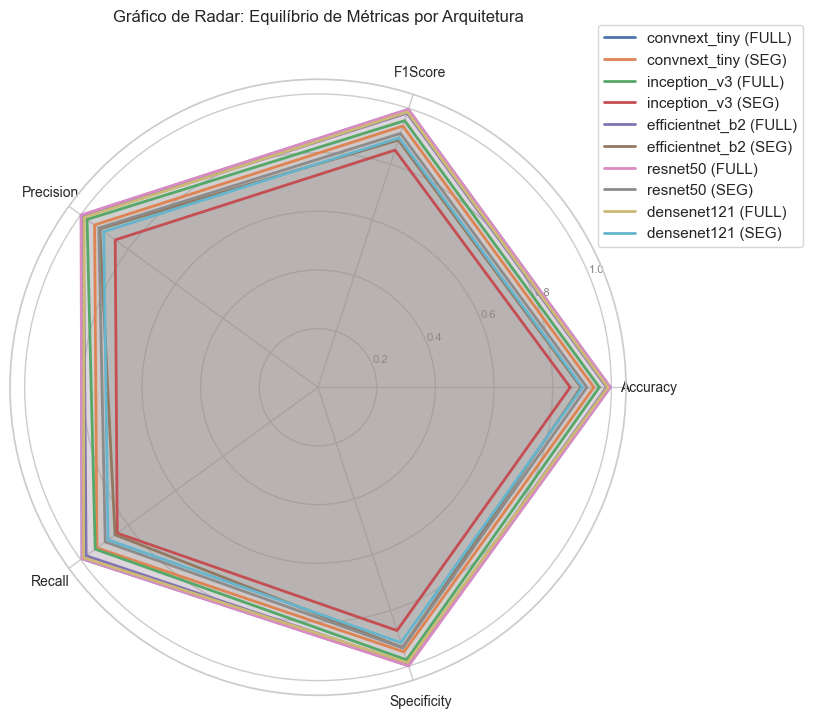

In [9]:
import numpy as np

# Apenas modelos FULL e SEG para visualização
df_pd = df.to_pandas()

# Filtrar colunas de métricas presentes no dataframe
possible_metrics = ['val_BinaryAccuracy', 'val_BinaryF1Score', 'val_BinaryPrecision', 'val_BinaryRecall', 'val_BinarySpecificity']
metrics = [m for m in possible_metrics if m in df_pd.columns]

if len(metrics) > 2:
    N = len(metrics)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for i, row in df_pd.iterrows():
        values = row[metrics].values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=f"{row.get('Architecture', row['Name'])} ({row.get('Dataset_Type', '')})")
        ax.fill(angles, values, alpha=0.1)

    plt.xticks(angles[:-1], [m.replace('val_Binary', '') for m in metrics], size=10)
    plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=8)
    plt.ylim(0, 1.05)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.title("Gráfico de Radar: Equilíbrio de Métricas por Arquitetura", y=1.08)
    plt.show()


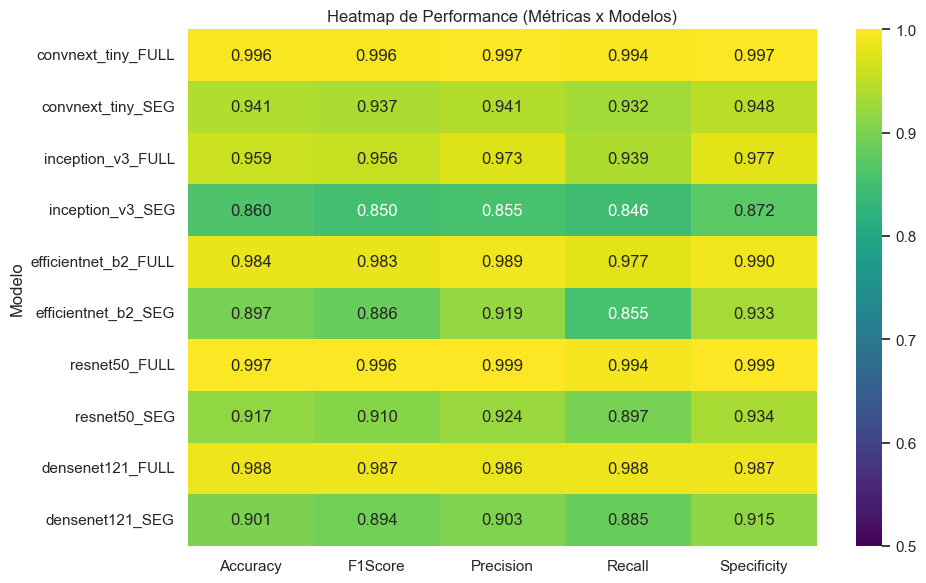

In [10]:
if 'Architecture' in df_pd.columns and 'Dataset_Type' in df_pd.columns:
    df_pd['Model_Type'] = df_pd['Architecture'] + "_" + df_pd['Dataset_Type']
else:
    df_pd['Model_Type'] = df_pd['Name']

if len(metrics) > 0:
    heatmap_data = df_pd.set_index('Model_Type')[metrics]
    heatmap_data.columns = [m.replace('val_Binary', '') for m in heatmap_data.columns]
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt='.3f', vmin=0.5, vmax=1.0)
    plt.title("Heatmap de Performance (Métricas x Modelos)")
    plt.ylabel("Modelo")
    plt.tight_layout()
    plt.show()


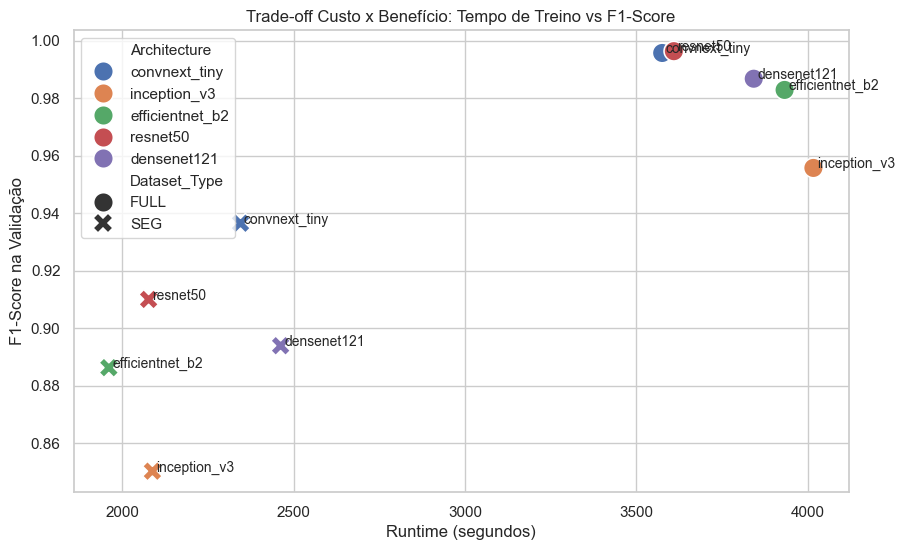

In [11]:
if 'Runtime' in df_pd.columns and 'val_BinaryF1Score' in df_pd.columns:
    plt.figure(figsize=(10, 6))
    arch_col = 'Architecture' if 'Architecture' in df_pd.columns else 'Name'
    dataset_col = 'Dataset_Type' if 'Dataset_Type' in df_pd.columns else None
    
    if dataset_col:
        sns.scatterplot(data=df_pd, x='Runtime', y='val_BinaryF1Score', hue=arch_col, style=dataset_col, s=200)
    else:
        sns.scatterplot(data=df_pd, x='Runtime', y='val_BinaryF1Score', hue=arch_col, s=200)
        
    for i, row in df_pd.iterrows():
        plt.text(row['Runtime'] + 10, row['val_BinaryF1Score'], row[arch_col], fontsize=10)
        
    plt.title("Trade-off Custo x Benefício: Tempo de Treino vs F1-Score")
    plt.xlabel("Runtime (segundos)")
    plt.ylabel("F1-Score na Validação")
    plt.grid(True)
    plt.show()


### Distribuição do Perfil de Erro nas Imagens
Aqui carregamos os arquivos reais de predição (`preds_*.csv`) para identificar como a arquitetura se comporta olhando para todas as imagens do conjunto de validação.


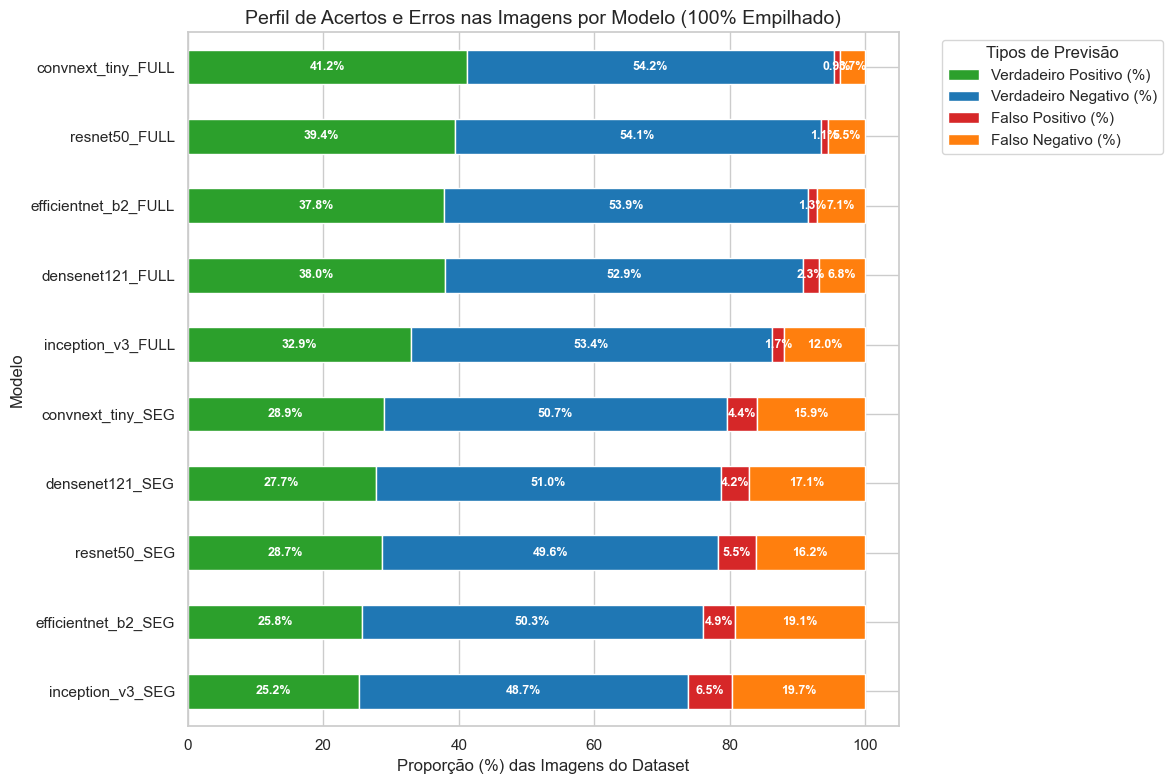

In [12]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

output_dirs = glob.glob('../outputs/*_GU')
error_profiles = []

for d in output_dirs:
    model_name = os.path.basename(d)
    preds_file = glob.glob(f"{d}/preds_*.csv")
    if preds_file:
        df_preds = pd.read_csv(preds_file[0])
        # Calcular Verdadeiros Positivos (TP), Verdadeiros Negativos (TN), Falsos Positivos (FP), Falsos Negativos (FN)
        if 'real' in df_preds.columns and 'pred_atual' in df_preds.columns:
            tp = len(df_preds[(df_preds['real'] == 1) & (df_preds['pred_atual'] == 1)])
            tn = len(df_preds[(df_preds['real'] == 0) & (df_preds['pred_atual'] == 0)])
            fp = len(df_preds[(df_preds['real'] == 0) & (df_preds['pred_atual'] == 1)])
            fn = len(df_preds[(df_preds['real'] == 1) & (df_preds['pred_atual'] == 0)])
            total = len(df_preds)
            
            if total > 0:
                error_profiles.append({
                    'Model': model_name.replace('_GU', ''),
                    'Verdadeiro Positivo (%)': tp / total * 100,
                    'Verdadeiro Negativo (%)': tn / total * 100,
                    'Falso Positivo (%)': fp / total * 100,
                    'Falso Negativo (%)': fn / total * 100
                })

if error_profiles:
    df_errors = pd.DataFrame(error_profiles).set_index('Model')
    # Ordenar pela soma de acertos
    df_errors['Acertos Totais'] = df_errors['Verdadeiro Positivo (%)'] + df_errors['Verdadeiro Negativo (%)']
    df_errors = df_errors.sort_values(by='Acertos Totais', ascending=True).drop(columns=['Acertos Totais'])
    
    # Cores personalizadas: Verdes/Azuis para acertos, Vermelhos/Laranjas para erros
    colors = ['#2ca02c', '#1f77b4', '#d62728', '#ff7f0e']
    
    ax = df_errors.plot(kind='barh', stacked=True, figsize=(12, 8), color=colors)
    plt.title("Perfil de Acertos e Erros nas Imagens por Modelo (100% Empilhado)", fontsize=14)
    plt.xlabel("Proporção (%) das Imagens do Dataset", fontsize=12)
    plt.ylabel("Modelo", fontsize=12)
    plt.legend(title="Tipos de Previsão", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Adicionar porcentagens dentro das barras se houver espaço
    for c in ax.containers:
        ax.bar_label(c, fmt='%.1f%%', label_type='center', color='white', weight='bold', fontsize=9)
        
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum arquivo de predição contendo 'real' e 'pred_atual' foi encontrado.")
